In [1]:
# Cell 1 — Install all required libraries
!pip install -q transformers datasets peft accelerate evaluate \
             scikit-learn matplotlib seaborn seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import load_dataset
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

print("All imports successful.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

All imports successful.
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


In [3]:
# Cell 3 — Global config (single source of truth — we touch this later as needed)
CONFIG = {
    "model_name"      : "roberta-base",
    "max_length"      : 128,          # will confirm in EDA
    "batch_size"      : 16,
    "num_epochs"      : 10,
    "learning_rate"   : 2e-4,
    "weight_decay"    : 0.01,
    "lora_r"          : 16,
    "lora_alpha"      : 32,
    "lora_dropout"    : 0.1,
    "seed"            : 42,
    "val_split"       : 0.1,
    "label2id"        : {"positive": 0, "negative": 1, "neutral": 2, "conflict": 3},
    "id2label"        : {0: "positive", 1: "negative", 2: "neutral", 3: "conflict"},
    "num_labels"      : 4,
    "output_dir"      : "./absa-model",
}

# Reproducibility
import random
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

print("Config set. Ready for Phase 2.")

Config set. Ready for Phase 2.


In [4]:
# Cell 4 — Load dataset
from datasets import load_dataset

raw = load_dataset("tomaarsen/setfit-absa-semeval-laptops")
print(raw)
print("\nColumn names:", raw["train"].column_names)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/117k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/30.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2358 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/654 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'span', 'label', 'ordinal'],
        num_rows: 2358
    })
    test: Dataset({
        features: ['text', 'span', 'label', 'ordinal'],
        num_rows: 654
    })
})

Column names: ['text', 'span', 'label', 'ordinal']


In [11]:
# Cell 5 — Load only from train split (test split has no labels)
def hf_to_df(split):
    rows = []
    for ex in split:
        sentence = ex["text"]
        aspect   = ex["span"]
        label    = ex["label"]
        if not sentence or not aspect or not label:
            continue
        rows.append({
            "sentence" : sentence.strip(),
            "aspect"   : aspect.strip(),
            "label"    : label.strip().lower(),
        })
    return pd.DataFrame(rows)

full_df = hf_to_df(raw["train"])

print(f"Total usable rows : {len(full_df)}")
display(full_df.head(5))
print("\nLabel counts:")
print(full_df["label"].value_counts())

Total usable rows : 2358


,sentence,aspect,label
0,I charge it at night and skip taking the cord ...,cord,neutral
1,I charge it at night and skip taking the cord ...,battery life,positive
2,The tech guy then said the service center does...,service center,negative
3,The tech guy then said the service center does...,"""sales"" team",negative
4,The tech guy then said the service center does...,tech guy,neutral



Label counts:
label
positive    987
negative    866
neutral     460
conflict     45
Name: count, dtype: int64


In [12]:
# Cell 6 — Validate labels
all_labels = set(full_df["label"].unique())
expected   = set(CONFIG["label2id"].keys())
unexpected = all_labels - expected

if unexpected:
    print(f"WARNING — unexpected labels found: {unexpected}")
    full_df = full_df[full_df["label"].isin(expected)].reset_index(drop=True)
else:
    print(f"All labels valid: {all_labels}")

print(f"Total rows after validation : {len(full_df)}")

All labels valid: {'negative', 'positive', 'conflict', 'neutral'}
Total rows after validation : 2358


=== Label Distribution ===
label
positive    987
negative    866
neutral     460
conflict     45
Name: count, dtype: int64


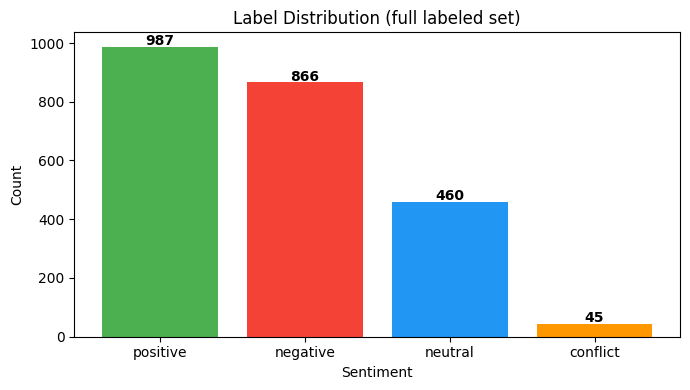

In [13]:
# Cell 7 — Class distribution plot
counts = full_df["label"].value_counts()
print("=== Label Distribution ===")
print(counts)

plt.figure(figsize=(7, 4))
colors = ["#4CAF50", "#F44336", "#2196F3", "#FF9800"]
bars   = plt.bar(counts.index, counts.values,
                 color=colors[:len(counts)])
plt.title("Label Distribution (full labeled set)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
for bar, v in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Cell 8 — Compute class weights (inverse frequency)
label_order   = ["positive", "negative", "neutral", "conflict"]
total         = len(full_df)
class_weights = []

print("Class weights:")
for lbl in label_order:
    count = (full_df["label"] == lbl).sum()
    w     = total / (CONFIG["num_labels"] * count) if count > 0 else 0.0
    class_weights.append(round(w, 4))
    print(f"  {lbl:10s} — count: {count:4d}  weight: {w:.4f}")

CONFIG["class_weights"] = class_weights

Class weights:
  positive   — count:  987  weight: 0.5973
  negative   — count:  866  weight: 0.6807
  neutral    — count:  460  weight: 1.2815
  conflict   — count:   45  weight: 13.1000


In [15]:
# Cell 9 — Stratified 80/10/10 train/val/test split
from sklearn.model_selection import train_test_split

# First split off 20% for val+test
train_df, temp_df = train_test_split(
    full_df,
    test_size    = 0.2,
    random_state = CONFIG["seed"],
    stratify     = full_df["label"],
)

# Split that 20% evenly into val and test
val_df, test_df = train_test_split(
    temp_df,
    test_size    = 0.5,
    random_state = CONFIG["seed"],
    stratify     = temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)} rows")
print(f"Val   : {len(val_df)}   rows")
print(f"Test  : {len(test_df)}  rows")

print("\nTrain label distribution:")
print(train_df["label"].value_counts())
print("\nVal label distribution:")
print(val_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train : 1886 rows
Val   : 236   rows
Test  : 236  rows

Train label distribution:
label
positive    789
negative    693
neutral     368
conflict     36
Name: count, dtype: int64

Val label distribution:
label
positive    99
negative    87
neutral     46
conflict     4
Name: count, dtype: int64

Test label distribution:
label
positive    99
negative    86
neutral     46
conflict     5
Name: count, dtype: int64


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== Token Length Stats ===
count    2358.000000
mean       29.147583
std        12.599820
min         8.000000
25%        20.000000
50%        27.000000
75%        35.000000
max        95.000000
Name: token_length, dtype: float64

95th percentile : 54
99th percentile : 74
Max             : 95


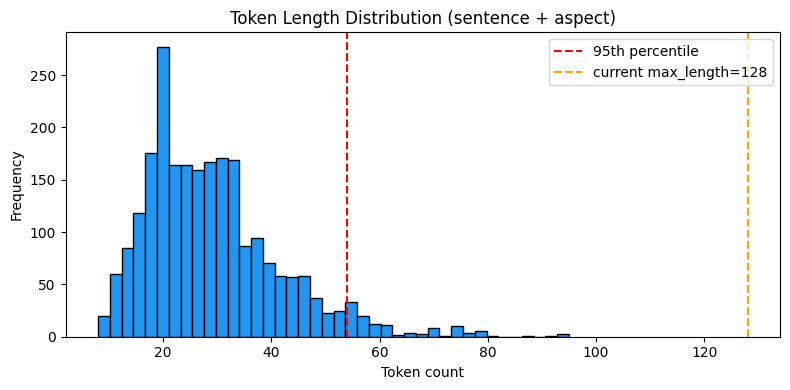

In [16]:
# Cell 10 — Token length distribution (sentence + aspect combined as model will see it)
# Format: "sentence [SEP] aspect" — this is exactly how we'll feed the model
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def get_token_length(row):
    # Mimics exact input format we'll use in training
    encoded = tokenizer(
        row["sentence"],
        row["aspect"],
        truncation=False,
        add_special_tokens=True,
    )
    return len(encoded["input_ids"])

full_df["token_length"] = full_df.apply(get_token_length, axis=1)

print("=== Token Length Stats ===")
print(full_df["token_length"].describe())
print(f"\n95th percentile : {full_df['token_length'].quantile(0.95):.0f}")
print(f"99th percentile : {full_df['token_length'].quantile(0.99):.0f}")
print(f"Max             : {full_df['token_length'].max()}")

plt.figure(figsize=(8, 4))
plt.hist(full_df["token_length"], bins=40, color="#2196F3", edgecolor="black")
plt.axvline(full_df["token_length"].quantile(0.95),
            color="red", linestyle="--", label="95th percentile")
plt.axvline(128, color="orange", linestyle="--", label="current max_length=128")
plt.title("Token Length Distribution (sentence + aspect)")
plt.xlabel("Token count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Cell 11 — Top aspect terms per sentiment class
print("=== Top 10 Aspect Terms per Sentiment ===\n")
for lbl in ["positive", "negative", "neutral", "conflict"]:
    subset = full_df[full_df["label"] == lbl]["aspect"].str.lower()
    top    = Counter(subset).most_common(10)
    print(f"[{lbl.upper()}]")
    for term, cnt in top:
        print(f"  {term:25s} {cnt}")
    print()

=== Top 10 Aspect Terms per Sentiment ===

[POSITIVE]
  use                       49
  price                     46
  battery life              32
  screen                    31
  keyboard                  23
  features                  22
  programs                  19
  speed                     18
  quality                   16
  runs                      15

[NEGATIVE]
  battery                   32
  screen                    23
  keyboard                  19
  windows                   18
  battery life              17
  software                  17
  hard drive                16
  warranty                  13
  vista                     12
  motherboard               11

[NEUTRAL]
  warranty                  13
  hard drive                11
  programs                  9
  features                  8
  windows                   8
  keyboard                  8
  software                  7
  games                     7
  screen                    6
  extended warranty         6



In [18]:
# Cell 12 — Update config based on EDA findings
CONFIG["max_length"] = 96
print(f"max_length updated to: {CONFIG['max_length']}")
print(f"class_weights confirmed: {CONFIG['class_weights']}")

max_length updated to: 96
class_weights confirmed: [np.float64(0.5973), np.float64(0.6807), np.float64(1.2815), np.float64(13.1)]


In [19]:
# Cell 13 — Dataset class
# Input format: "sentence [SEP] aspect" → label
# This is the correct ABSA sequence classification approach

class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_length, label2id):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.label2id   = label2id

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        sentence = row["sentence"]
        aspect   = row["aspect"]
        label    = self.label2id[row["label"]]

        encoding = self.tokenizer(
            sentence,
            aspect,
            max_length      = self.max_length,
            padding         = "max_length",
            truncation      = True,
            return_tensors  = "pt",
        )

        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "labels"         : torch.tensor(label, dtype=torch.long),
        }

print("ABSADataset class defined.")

ABSADataset class defined.


In [20]:
# Cell 14 — Instantiate datasets and dataloaders
train_dataset = ABSADataset(train_df, tokenizer, CONFIG["max_length"], CONFIG["label2id"])
val_dataset   = ABSADataset(val_df,   tokenizer, CONFIG["max_length"], CONFIG["label2id"])
test_dataset  = ABSADataset(test_df,  tokenizer, CONFIG["max_length"], CONFIG["label2id"])

train_loader  = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"], shuffle=False)
test_loader   = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"], shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Sanity check — inspect one batch
batch = next(iter(train_loader))
print(f"\nBatch input_ids shape      : {batch['input_ids'].shape}")
print(f"Batch attention_mask shape : {batch['attention_mask'].shape}")
print(f"Batch labels shape         : {batch['labels'].shape}")
print(f"Sample labels in batch     : {batch['labels'][:8].tolist()}")

# Decode one sample to confirm format is correct
sample_ids = batch["input_ids"][0]
print(f"\nDecoded sample input:\n{tokenizer.decode(sample_ids, skip_special_tokens=False)}")

Train batches : 118
Val   batches : 15
Test  batches : 15

Batch input_ids shape      : torch.Size([16, 96])
Batch attention_mask shape : torch.Size([16, 96])
Batch labels shape         : torch.Size([16])
Sample labels in batch     : [1, 0, 0, 3, 2, 1, 0, 0]

Decoded sample input:
<s>the only fact i dont like about apples is they generally use safari and i dont use safari but after i install Mozzilla firfox i love every single bit about it.</s></s>safari</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>


In [21]:
# Cell 15 — Load RoBERTa + apply LoRA for sequence classification
from transformers import AutoModelForSequenceClassification
from peft import get_peft_model, LoraConfig, TaskType

model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels  = CONFIG["num_labels"],
    id2label    = CONFIG["id2label"],
    label2id    = CONFIG["label2id"],
    ignore_mismatched_sizes = True,
)

lora_config = LoraConfig(
    task_type    = TaskType.SEQ_CLS,
    r            = CONFIG["lora_r"],
    lora_alpha   = CONFIG["lora_alpha"],
    lora_dropout = CONFIG["lora_dropout"],
    # Target all attention projection layers for maximum adaptation
    target_modules = ["query", "key", "value", "dense"],
    bias           = "none",
)

model = get_peft_model(model, lora_config)
model.to(DEVICE)

print("Trainable parameters:")
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters:
trainable params: 3,247,876 || all params: 127,896,584 || trainable%: 2.5395


In [22]:
# Cell 16 — Class-weighted loss + custom trainer
from transformers import Trainer, TrainingArguments
from torch.nn import CrossEntropyLoss

# Build weight tensor in correct label order: positive=0, negative=1, neutral=2, conflict=3
weight_tensor = torch.tensor(
    CONFIG["class_weights"],
    dtype=torch.float32
).to(DEVICE)

print("Loss weights tensor:", weight_tensor)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = CrossEntropyLoss(weight=weight_tensor)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

Loss weights tensor: tensor([ 0.5973,  0.6807,  1.2815, 13.1000], device='cuda:0')


In [23]:
# Cell 17 — Metrics function (macro F1 is our north star)
from sklearn.metrics import f1_score, classification_report
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds          = np.argmax(logits, axis=-1)

    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    
    # Also compute 3-class F1 (excluding conflict) for reference
    mask        = labels != CONFIG["label2id"]["conflict"]
    macro_f1_3  = f1_score(
        labels[mask], preds[mask],
        average="macro", zero_division=0
    ) if mask.sum() > 0 else 0.0

    return {
        "macro_f1"   : round(macro_f1,   4),
        "macro_f1_3" : round(macro_f1_3, 4),
    }

In [24]:
# Cell 18 — Training arguments
training_args = TrainingArguments(
    output_dir                  = CONFIG["output_dir"],
    num_train_epochs            = CONFIG["num_epochs"],
    per_device_train_batch_size = CONFIG["batch_size"],
    per_device_eval_batch_size  = CONFIG["batch_size"],
    learning_rate               = CONFIG["learning_rate"],
    weight_decay                = CONFIG["weight_decay"],
    lr_scheduler_type           = "cosine",        # cosine decay — better than linear for small datasets
    warmup_ratio                = 0.1,             # 10% warmup steps
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    greater_is_better           = True,
    logging_strategy            = "epoch",
    fp16                        = torch.cuda.is_available(),
    seed                        = CONFIG["seed"],
    report_to                   = "none",
)

print("Training args set.")
print(f"  Epochs        : {CONFIG['num_epochs']}")
print(f"  LR            : {CONFIG['learning_rate']}")
print(f"  Batch size    : {CONFIG['batch_size']}")
print(f"  Scheduler     : cosine with 10% warmup")
print(f"  Best model by : macro_f1")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training args set.
  Epochs        : 10
  LR            : 0.0002
  Batch size    : 16
  Scheduler     : cosine with 10% warmup
  Best model by : macro_f1


In [25]:
# Cell 19 — Instantiate trainer and train
from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Starting training...\n")
trainer.train()

Starting training...



Epoch,Training Loss,Validation Loss,Macro F1,Macro F1 3
1,1.390269,1.190841,0.401000,0.539600
2,1.087944,0.829198,0.573500,0.578700
3,0.824083,0.909028,0.493500,0.497600
4,0.634059,0.830579,0.593400,0.573800
5,0.462185,0.893358,0.604400,0.586000
6,0.345968,0.996943,0.601500,0.606600
7,0.265447,1.004988,0.596100,0.601300
8,0.225251,1.015723,0.602000,0.607300


TrainOutput(global_step=472, training_loss=0.6544007204346738, metrics={'train_runtime': 183.3694, 'train_samples_per_second': 102.853, 'train_steps_per_second': 3.218, 'total_flos': 772580818870272.0, 'train_loss': 0.6544007204346738, 'epoch': 8.0})

=== Validation Set — Per-Class Report ===

              precision    recall  f1-score   support

    positive     0.9241    0.7374    0.8202        99
    negative     0.9200    0.7931    0.8519        87
     neutral     0.5625    0.7826    0.6545        46
    conflict     0.0556    0.2500    0.0909         4

    accuracy                         0.7585       236
   macro avg     0.6155    0.6408    0.6044       236
weighted avg     0.8374    0.7585    0.7872       236

=== Confusion Matrix ===


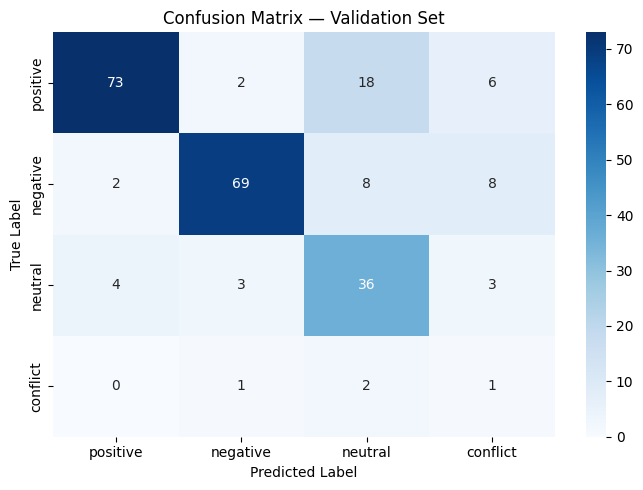

In [26]:
# Cell 20 — Detailed evaluation on validation set
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on validation set
val_preds_output = trainer.predict(val_dataset)
val_preds        = np.argmax(val_preds_output.predictions, axis=-1)
val_labels       = val_preds_output.label_ids

label_names = ["positive", "negative", "neutral", "conflict"]

print("=== Validation Set — Per-Class Report ===\n")
print(classification_report(
    val_labels, val_preds,
    target_names = label_names,
    digits       = 4,
    zero_division = 0,
))

print("=== Confusion Matrix ===")
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)
plt.title("Confusion Matrix — Validation Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [27]:
# Cell 21 — Merge conflict into neutral, update config
full_df["label"]  = full_df["label"].replace("conflict", "neutral")
train_df["label"] = train_df["label"].replace("conflict", "neutral")
val_df["label"]   = val_df["label"].replace("conflict", "neutral")
test_df["label"]  = test_df["label"].replace("conflict", "neutral")

# Update config for 3 classes
CONFIG["num_labels"] = 3
CONFIG["label2id"]   = {"positive": 0, "negative": 1, "neutral": 2}
CONFIG["id2label"]   = {0: "positive", 1: "negative", 2: "neutral"}

# Recompute class weights
label_order   = ["positive", "negative", "neutral"]
total         = len(train_df)
class_weights = []

print("Updated class weights:")
for lbl in label_order:
    count = (train_df["label"] == lbl).sum()
    w     = total / (CONFIG["num_labels"] * count) if count > 0 else 0.0
    class_weights.append(round(w, 4))
    print(f"  {lbl:10s} — count: {count:4d}  weight: {w:.4f}")

CONFIG["class_weights"] = class_weights

print(f"\nLabel distribution after merge:")
print(train_df["label"].value_counts())

Updated class weights:
  positive   — count:  789  weight: 0.7968
  negative   — count:  693  weight: 0.9072
  neutral    — count:  404  weight: 1.5561

Label distribution after merge:
label
positive    789
negative    693
neutral     404
Name: count, dtype: int64


In [28]:
# Cell 22 — Rebuild datasets with updated labels
train_dataset = ABSADataset(train_df, tokenizer, CONFIG["max_length"], CONFIG["label2id"])
val_dataset   = ABSADataset(val_df,   tokenizer, CONFIG["max_length"], CONFIG["label2id"])
test_dataset  = ABSADataset(test_df,  tokenizer, CONFIG["max_length"], CONFIG["label2id"])

# Verify one sample decodes correctly
sample = train_dataset[0]
print("Sample label id  :", sample["labels"].item())
print("Sample label name:", CONFIG["id2label"][sample["labels"].item()])
print("Decoded input    :", tokenizer.decode(sample["input_ids"], skip_special_tokens=False).replace("<pad>","").strip())

Sample label id  : 1
Sample label name: negative
Decoded input    : <s>This computer was so challenging to carry and handle.</s></s>carry</s>


In [29]:
# Cell 23 — Reload fresh RoBERTa + LoRA (3-class, clean slate)
from transformers import AutoModelForSequenceClassification
from peft import get_peft_model, LoraConfig, TaskType

model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels = CONFIG["num_labels"],
    id2label   = CONFIG["id2label"],
    label2id   = CONFIG["label2id"],
    ignore_mismatched_sizes = True,
)

lora_config = LoraConfig(
    task_type      = TaskType.SEQ_CLS,
    r              = CONFIG["lora_r"],
    lora_alpha     = CONFIG["lora_alpha"],
    lora_dropout   = CONFIG["lora_dropout"],
    target_modules = ["query", "key", "value", "dense"],
    bias           = "none",
)

model = get_peft_model(model, lora_config)
model.to(DEVICE)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,247,107 || all params: 127,895,046 || trainable%: 2.5389


In [30]:
# Cell 24 — Rebuild weighted loss with 3-class weights
weight_tensor = torch.tensor(
    CONFIG["class_weights"],
    dtype = torch.float32
).to(DEVICE)

print("Loss weight tensor:", weight_tensor)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = CrossEntropyLoss(weight=weight_tensor)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

Loss weight tensor: tensor([0.7968, 0.9072, 1.5561], device='cuda:0')


In [31]:
# Cell 25 — Updated metrics for 3 classes
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds          = np.argmax(logits, axis=-1)
    macro_f1       = f1_score(labels, preds, average="macro", zero_division=0)
    weighted_f1    = f1_score(labels, preds, average="weighted", zero_division=0)
    return {
        "macro_f1"    : round(macro_f1,    4),
        "weighted_f1" : round(weighted_f1, 4),
    }

In [32]:
# Cell 26 — Updated training args
# Key improvements over last run:
# 1. Lower LR — previous run overfit after epoch 5, cosine decay will be gentler
# 2. More warmup — small dataset benefits from slower start
# 3. Label smoothing — reduces overconfidence, helps generalization
# 4. Higher early stopping patience — give model more room before stopping

CONFIG["learning_rate"] = 1e-4

training_args = TrainingArguments(
    output_dir                  = CONFIG["output_dir"],
    num_train_epochs            = 15,
    per_device_train_batch_size = CONFIG["batch_size"],
    per_device_eval_batch_size  = CONFIG["batch_size"],
    learning_rate               = CONFIG["learning_rate"],
    weight_decay                = CONFIG["weight_decay"],
    lr_scheduler_type           = "cosine",
    warmup_ratio                = 0.15,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    greater_is_better           = True,
    logging_strategy            = "epoch",
    label_smoothing_factor      = 0.1,
    fp16                        = torch.cuda.is_available(),
    seed                        = CONFIG["seed"],
    report_to                   = "none",
)

print("Training args updated.")
print(f"  LR             : {CONFIG['learning_rate']}")
print(f"  Label smoothing: 0.1")
print(f"  Warmup ratio   : 0.15")
print(f"  Max epochs     : 15 with early stopping patience 4")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training args updated.
  LR             : 0.0001
  Label smoothing: 0.1
  Warmup ratio   : 0.15
  Max epochs     : 15 with early stopping patience 4


In [33]:
# Cell 27 — Train
trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=4)],
)

print("Starting 3-class training...\n")
trainer.train()

Starting 3-class training...



Epoch,Training Loss,Validation Loss,Macro F1,Weighted F1
1,1.105689,1.094446,0.179600,0.198600
2,0.986161,0.751500,0.656800,0.710000
3,0.695907,0.584462,0.753300,0.779400
4,0.557252,0.542427,0.740200,0.764700
5,0.462821,0.512295,0.764900,0.788400
6,0.391596,0.447325,0.810000,0.831300
7,0.341191,0.493024,0.795700,0.815300
8,0.295081,0.475801,0.810900,0.831700
9,0.243633,0.552018,0.797200,0.819900
10,0.223331,0.585889,0.796800,0.820000


TrainOutput(global_step=708, training_loss=0.4730997139451194, metrics={'train_runtime': 281.8895, 'train_samples_per_second': 100.358, 'train_steps_per_second': 3.14, 'total_flos': 1158851178888192.0, 'train_loss': 0.4730997139451194, 'epoch': 12.0})

=== TEST SET — Per-Class Report ===

              precision    recall  f1-score   support

    positive     0.9247    0.8687    0.8958        99
    negative     0.8523    0.8721    0.8621        86
     neutral     0.6727    0.7255    0.6981        51

    accuracy                         0.8390       236
   macro avg     0.8166    0.8221    0.8187       236
weighted avg     0.8439    0.8390    0.8408       236

=== Confusion Matrix — Test Set ===


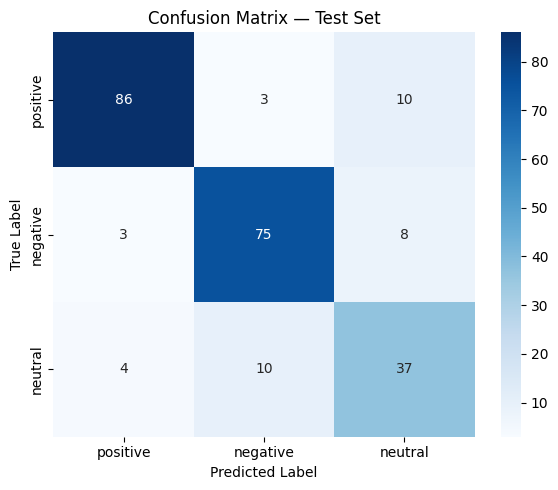

In [34]:
# Cell 28 — Full evaluation on test set
test_preds_output = trainer.predict(test_dataset)
test_preds        = np.argmax(test_preds_output.predictions, axis=-1)
test_labels       = test_preds_output.label_ids

label_names = ["positive", "negative", "neutral"]

print("=== TEST SET — Per-Class Report ===\n")
print(classification_report(
    test_labels, test_preds,
    target_names  = label_names,
    digits        = 4,
    zero_division = 0,
))

print("=== Confusion Matrix — Test Set ===")
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [35]:
# Cell 29 — Live inference on custom examples
def predict_sentiment(sentence, aspect):
    model.eval()
    encoding = tokenizer(
        sentence,
        aspect,
        max_length     = CONFIG["max_length"],
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**encoding).logits

    probs     = torch.softmax(logits, dim=-1).squeeze(0)
    pred_id   = torch.argmax(probs).item()
    pred_label = CONFIG["id2label"][pred_id]

    print(f"Sentence : {sentence}")
    print(f"Aspect   : {aspect}")
    print(f"Prediction : {pred_label.upper()}")
    for i, lbl in CONFIG["id2label"].items():
        print(f"  {lbl:10s}: {probs[i].item():.4f}")
    print()

# Test on real examples
predict_sentiment(
    "The battery life on this laptop is absolutely amazing, lasts all day.",
    "battery life"
)
predict_sentiment(
    "The keyboard feels cheap and the keys are hard to press.",
    "keyboard"
)
predict_sentiment(
    "The screen is okay I guess, nothing special about it.",
    "screen"
)
predict_sentiment(
    "I paid way too much for what this laptop offers.",
    "price"
)
predict_sentiment(
    "The software that comes preinstalled is mostly bloatware.",
    "software"
)

Sentence : The battery life on this laptop is absolutely amazing, lasts all day.
Aspect   : battery life
Prediction : POSITIVE
  positive  : 0.9972
  negative  : 0.0015
  neutral   : 0.0013

Sentence : The keyboard feels cheap and the keys are hard to press.
Aspect   : keyboard
Prediction : POSITIVE
  positive  : 0.9776
  negative  : 0.0101
  neutral   : 0.0123

Sentence : The screen is okay I guess, nothing special about it.
Aspect   : screen
Prediction : POSITIVE
  positive  : 0.6180
  negative  : 0.0161
  neutral   : 0.3659

Sentence : I paid way too much for what this laptop offers.
Aspect   : price
Prediction : NEGATIVE
  positive  : 0.0030
  negative  : 0.9947
  neutral   : 0.0023

Sentence : The software that comes preinstalled is mostly bloatware.
Aspect   : software
Prediction : NEGATIVE
  positive  : 0.0075
  negative  : 0.9414
  neutral   : 0.0511



In [36]:
# Cell 30 — Test DeBERTa-ABSA zero-shot on same examples that failed before
from transformers import pipeline

absa_pipeline = pipeline(
    "text-classification",
    model  = "yangheng/deberta-v3-base-absa-v1.1",
    device = 0 if torch.cuda.is_available() else -1,
)

test_examples = [
    ("The battery life on this laptop is absolutely amazing, lasts all day.", "battery life"),
    ("The keyboard feels cheap and the keys are hard to press.",              "keyboard"),
    ("The screen is okay I guess, nothing special about it.",                 "screen"),
    ("I paid way too much for what this laptop offers.",                      "price"),
    ("The software that comes preinstalled is mostly bloatware.",             "software"),
]

print("=== DeBERTa-ABSA Zero-Shot Inference ===\n")
for sentence, aspect in test_examples:
    result = absa_pipeline(sentence, text_pair=aspect, top_k=None)
    # sort by label name for consistent display
    result_sorted = sorted(result, key=lambda x: x["label"])
    pred_label    = max(result, key=lambda x: x["score"])["label"]
    print(f"Sentence  : {sentence}")
    print(f"Aspect    : {aspect}")
    print(f"Prediction: {pred_label.upper()}")
    for r in result_sorted:
        print(f"  {r['label']:10s}: {r['score']:.4f}")
    print()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: yangheng/deberta-v3-base-absa-v1.1
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

=== DeBERTa-ABSA Zero-Shot Inference ===

Sentence  : The battery life on this laptop is absolutely amazing, lasts all day.
Aspect    : battery life
Prediction: NEGATIVE
  Negative  : 0.6505
  Neutral   : 0.0626
  Positive  : 0.2868

Sentence  : The keyboard feels cheap and the keys are hard to press.
Aspect    : keyboard
Prediction: POSITIVE
  Negative  : 0.1442
  Neutral   : 0.3162
  Positive  : 0.5396

Sentence  : The screen is okay I guess, nothing special about it.
Aspect    : screen
Prediction: POSITIVE
  Negative  : 0.1719
  Neutral   : 0.1751
  Positive  : 0.6531

Sentence  : I paid way too much for what this laptop offers.
Aspect    : price
Prediction: NEGATIVE
  Negative  : 0.7884
  Neutral   : 0.0390
  Positive  : 0.1726

Sentence  : The software that comes preinstalled is mostly bloatware.
Aspect    : software
Prediction: NEGATIVE
  Negative  : 0.9450
  Neutral   : 0.0183
  Positive  : 0.0366



In [37]:
# Cell 31 — Test on actual examples FROM the test set
model.eval()

def predict_sentiment(sentence, aspect, true_label=None):
    encoding = tokenizer(
        sentence,
        aspect,
        max_length     = CONFIG["max_length"],
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**encoding).logits

    probs      = torch.softmax(logits, dim=-1).squeeze(0)
    pred_id    = torch.argmax(probs).item()
    pred_label = CONFIG["id2label"][pred_id]
    correct    = "✓" if true_label == pred_label else "✗"

    print(f"Sentence   : {sentence}")
    print(f"Aspect     : {aspect}")
    print(f"Predicted  : {pred_label.upper()} {correct if true_label else ''}")
    if true_label:
        print(f"True label : {true_label.upper()}")
    for i, lbl in CONFIG["id2label"].items():
        print(f"  {lbl:10s}: {probs[i].item():.4f}")
    print()

# Sample 15 examples from test set — mix of all classes
sample = test_df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(5, len(x)), random_state=CONFIG["seed"])
).reset_index(drop=True)

print(f"=== Inference on {len(sample)} Real Test Set Examples ===\n")
for _, row in sample.iterrows():
    predict_sentiment(row["sentence"], row["aspect"], row["label"])

/tmp/ipykernel_55/1173909968.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = test_df.groupby("label", group_keys=False).apply(


=== Inference on 15 Real Test Set Examples ===

Sentence   : The only downfall is the battery only last 1.5-2.0 hrs when not plugged in.
Aspect     : battery
Predicted  : NEGATIVE ✓
True label : NEGATIVE
  positive  : 0.0024
  negative  : 0.9961
  neutral   : 0.0015

Sentence   : Externally the keys on my keyboard are falling off, after a few uses the paint is rubbing off the button below the mouse pad and where the heals of my hands sit, and the screen has a terrible glare.
Aspect     : screen
Predicted  : NEGATIVE ✓
True label : NEGATIVE
  positive  : 0.0017
  negative  : 0.9969
  neutral   : 0.0014

Sentence   : I had static in the output, and I had to reduce the sound output quality to "FM" as opposed to the default "CD.
Aspect     : sound output quality
Predicted  : NEGATIVE ✓
True label : NEGATIVE
  positive  : 0.0013
  negative  : 0.9766
  neutral   : 0.0221

Sentence   : then on top of it all their cusromer service center is in the middle east.
Aspect     : cusromer service cen

In [38]:
# Cell 32 — Augment neutral class via synonym replacement
# No external APIs — uses nlpaug which runs locally
!pip install nlpaug -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 7.8 MB/s eta 0:00:00a 0:00:01


In [40]:
# Cell 33 — FIXED: Augment neutral class via random word swap (no external dependencies)
import random
random.seed(CONFIG["seed"])

def random_swap_augment(sentence, n_swaps=2):
    """Randomly swap n pairs of words in a sentence."""
    words = sentence.split()
    if len(words) < 4:  # skip very short sentences
        return sentence
    words = words.copy()
    for _ in range(n_swaps):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return " ".join(words)

def random_delete_augment(sentence, del_prob=0.1):
    """Randomly delete words with probability del_prob."""
    words = sentence.split()
    if len(words) < 4:
        return sentence
    new_words = [w for w in words if random.random() > del_prob]
    return " ".join(new_words) if new_words else sentence

neutral_train = train_df[train_df["label"] == "neutral"].reset_index(drop=True)
print(f"Neutral samples before augmentation: {len(neutral_train)}")

augmented_rows = []
for _, row in neutral_train.iterrows():
    # Generate 2 augmented versions per neutral sample
    aug1 = random_swap_augment(row["sentence"], n_swaps=2)
    aug2 = random_delete_augment(row["sentence"], del_prob=0.1)
    for aug_sentence in [aug1, aug2]:
        augmented_rows.append({
            "sentence" : aug_sentence,
            "aspect"   : row["aspect"],
            "label"    : "neutral",
        })

aug_df = pd.DataFrame(augmented_rows)
print(f"Augmented neutral samples generated: {len(aug_df)}")
print(f"\nSample:")
print(f"  Original  : {neutral_train.iloc[0]['sentence']}")
print(f"  Swap aug  : {augmented_rows[0]['sentence']}")
print(f"  Delete aug: {augmented_rows[1]['sentence']}")

Neutral samples before augmentation: 404
Augmented neutral samples generated: 808

Sample:
  Original  : Another THREE weeks later I had my laptop back with a new mousepad, keys, and casing.
  Swap aug  : later THREE weeks back I had my laptop Another with a new mousepad, keys, and casing.
  Delete aug: Another THREE weeks later had laptop back a new mousepad, keys, and casing.


In [41]:
# Cell 34 — Merge augmented data into training set
train_df_aug = pd.concat([train_df, aug_df], ignore_index=True)

print("Label distribution after augmentation:")
print(train_df_aug["label"].value_counts())

# Recompute class weights with new distribution
total_aug     = len(train_df_aug)
label_order   = ["positive", "negative", "neutral"]
class_weights_aug = []

print("\nUpdated class weights:")
for lbl in label_order:
    count = (train_df_aug["label"] == lbl).sum()
    w     = total_aug / (CONFIG["num_labels"] * count) if count > 0 else 0.0
    class_weights_aug.append(round(w, 4))
    print(f"  {lbl:10s} — count: {count:4d}  weight: {w:.4f}")

CONFIG["class_weights"] = class_weights_aug

Label distribution after augmentation:
label
neutral     1212
positive     789
negative     693
Name: count, dtype: int64

Updated class weights:
  positive   — count:  789  weight: 1.1381
  negative   — count:  693  weight: 1.2958
  neutral    — count: 1212  weight: 0.7409


In [42]:
# Cell 35 — Rebuild dataset with augmented training data
train_dataset_aug = ABSADataset(
    train_df_aug, tokenizer,
    CONFIG["max_length"], CONFIG["label2id"]
)

# Val and test stay the same — never augment those
print(f"Augmented train size : {len(train_dataset_aug)}")
print(f"Val size             : {len(val_dataset)}")
print(f"Test size            : {len(test_dataset)}")

Augmented train size : 2694
Val size             : 236
Test size            : 236


In [43]:
# Cell 36 — Retrain with augmented data (fresh model)
model_aug = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels = CONFIG["num_labels"],
    id2label   = CONFIG["id2label"],
    label2id   = CONFIG["label2id"],
    ignore_mismatched_sizes = True,
)

model_aug = get_peft_model(model_aug, LoraConfig(
    task_type      = TaskType.SEQ_CLS,
    r              = CONFIG["lora_r"],
    lora_alpha     = CONFIG["lora_alpha"],
    lora_dropout   = CONFIG["lora_dropout"],
    target_modules = ["query", "key", "value", "dense"],
    bias           = "none",
))
model_aug.to(DEVICE)
model_aug.print_trainable_parameters()

weight_tensor_aug = torch.tensor(
    CONFIG["class_weights"],
    dtype=torch.float32
).to(DEVICE)

class WeightedTrainerAug(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = CrossEntropyLoss(weight=weight_tensor_aug)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args_aug = TrainingArguments(
    output_dir                  = "./absa-model-aug",
    num_train_epochs            = 15,
    per_device_train_batch_size = CONFIG["batch_size"],
    per_device_eval_batch_size  = CONFIG["batch_size"],
    learning_rate               = CONFIG["learning_rate"],
    weight_decay                = CONFIG["weight_decay"],
    lr_scheduler_type           = "cosine",
    warmup_ratio                = 0.15,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    greater_is_better           = True,
    logging_strategy            = "epoch",
    label_smoothing_factor      = 0.1,
    fp16                        = torch.cuda.is_available(),
    seed                        = CONFIG["seed"],
    report_to                   = "none",
)

trainer_aug = WeightedTrainerAug(
    model           = model_aug,
    args            = training_args_aug,
    train_dataset   = train_dataset_aug,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=4)],
)

print("Starting augmented training...\n")
trainer_aug.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 3,247,107 || all params: 127,895,046 || trainable%: 2.5389
Starting augmented training...



Epoch,Training Loss,Validation Loss,Macro F1,Weighted F1
1,1.096806,1.065390,0.429900,0.508400
2,0.815404,0.582698,0.751400,0.776000
3,0.540598,0.530450,0.772500,0.793800
4,0.428072,0.402376,0.788800,0.814000
5,0.337500,0.487019,0.803200,0.826900
6,0.278573,0.447755,0.779700,0.817500
7,0.213655,0.470672,0.822900,0.847400
8,0.161235,0.562273,0.809700,0.832400
9,0.147221,0.545154,0.813800,0.837300
10,0.126673,0.598785,0.815800,0.840900


TrainOutput(global_step=935, training_loss=0.3848807289001138, metrics={'train_runtime': 343.101, 'train_samples_per_second': 117.779, 'train_steps_per_second': 3.716, 'total_flos': 1517382283279104.0, 'train_loss': 0.3848807289001138, 'epoch': 11.0})

=== AUGMENTED MODEL — Test Set Report ===

              precision    recall  f1-score   support

    positive     0.8667    0.9192    0.8922        99
    negative     0.8081    0.9302    0.8649        86
     neutral     0.7500    0.4706    0.5783        51

    accuracy                         0.8263       236
   macro avg     0.8082    0.7733    0.7784       236
weighted avg     0.8201    0.8263    0.8144       236

Augmented Model Test Macro F1 : 0.7784
Previous Model Test Macro F1  : 0.8187
Improvement                   : +-0.0403


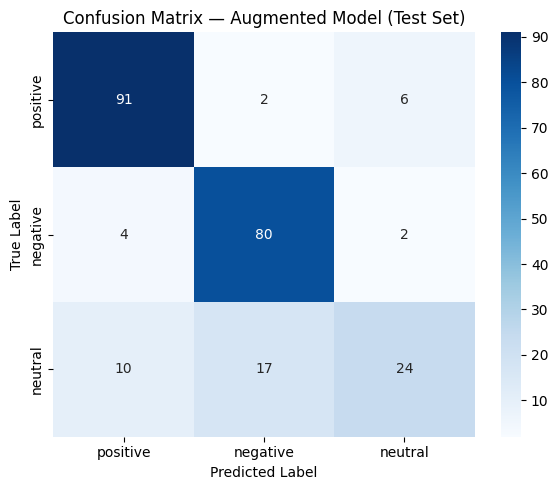

In [44]:
# Cell 37 — Evaluate augmented model on test set
test_preds_aug    = trainer_aug.predict(test_dataset)
test_preds_aug_ids = np.argmax(test_preds_aug.predictions, axis=-1)
test_labels_aug   = test_preds_aug.label_ids

label_names = ["positive", "negative", "neutral"]

print("=== AUGMENTED MODEL — Test Set Report ===\n")
print(classification_report(
    test_labels_aug, test_preds_aug_ids,
    target_names  = label_names,
    digits        = 4,
    zero_division = 0,
))

aug_macro_f1 = f1_score(test_labels_aug, test_preds_aug_ids,
                         average="macro", zero_division=0)
print(f"Augmented Model Test Macro F1 : {aug_macro_f1:.4f}")
print(f"Previous Model Test Macro F1  : 0.8187")
print(f"Improvement                   : +{aug_macro_f1 - 0.8187:.4f}")

# Confusion matrix
cm = confusion_matrix(test_labels_aug, test_preds_aug_ids)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)
plt.title("Confusion Matrix — Augmented Model (Test Set)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [45]:
# Cell 38 — Inference on examples using the ORIGINAL fine-tuned model
model.eval()

def predict_sentiment(sentence, aspect, true_label=None):
    encoding = tokenizer(
        sentence, aspect,
        max_length     = CONFIG["max_length"],
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**encoding).logits

    probs      = torch.softmax(logits, dim=-1).squeeze(0)
    pred_id    = torch.argmax(probs).item()
    pred_label = CONFIG["id2label"][pred_id]
    correct    = "✓" if true_label == pred_label else "✗"

    print(f"Sentence  : {sentence}")
    print(f"Aspect    : {aspect}")
    print(f"Predicted : {pred_label.upper()} {correct if true_label else ''}")
    if true_label:
        print(f"True label: {true_label.upper()}")
    for i, lbl in CONFIG["id2label"].items():
        print(f"  {lbl:10s}: {probs[i].item():.4f}")
    print()

# Mix of easy and hard custom examples
examples = [
    ("The battery life on this laptop is absolutely incredible.",  "battery life",  None),
    ("The keyboard feels cheap and breaks after a few weeks.",      "keyboard",      None),
    ("The screen resolution is 1080p.",                             "screen",        None),
    ("I love the price, best value for money I have seen.",         "price",         None),
    ("The customer service took 3 weeks to respond to my email.",   "customer service", None),
    ("The laptop comes with Windows 11 preinstalled.",              "Windows 11",    None),
    ("Fast boot time but the fan is annoyingly loud.",              "boot time",     None),
    ("Fast boot time but the fan is annoyingly loud.",              "fan",           None),
]

print("=== Custom Inference Examples ===\n")
for sentence, aspect, true_label in examples:
    predict_sentiment(sentence, aspect, true_label)

=== Custom Inference Examples ===

Sentence  : The battery life on this laptop is absolutely incredible.
Aspect    : battery life
Predicted : POSITIVE 
  positive  : 0.9952
  negative  : 0.0025
  neutral   : 0.0023

Sentence  : The keyboard feels cheap and breaks after a few weeks.
Aspect    : keyboard
Predicted : POSITIVE 
  positive  : 0.9522
  negative  : 0.0309
  neutral   : 0.0169

Sentence  : The screen resolution is 1080p.
Aspect    : screen
Predicted : NEUTRAL 
  positive  : 0.0099
  negative  : 0.0063
  neutral   : 0.9838

Sentence  : I love the price, best value for money I have seen.
Aspect    : price
Predicted : POSITIVE 
  positive  : 0.9985
  negative  : 0.0010
  neutral   : 0.0005

Sentence  : The customer service took 3 weeks to respond to my email.
Aspect    : customer service
Predicted : NEGATIVE 
  positive  : 0.0017
  negative  : 0.9955
  neutral   : 0.0028

Sentence  : The laptop comes with Windows 11 preinstalled.
Aspect    : Windows 11
Predicted : NEUTRAL 
  posi

In [46]:
# Cell 39 — Baseline: vanilla RoBERTa with NO fine-tuning
# Fresh model, same architecture, NO LoRA, NO training — just raw pretrained weights
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels = CONFIG["num_labels"],
    id2label   = CONFIG["id2label"],
    label2id   = CONFIG["label2id"],
    ignore_mismatched_sizes = True,
)
baseline_model.to(DEVICE)
baseline_model.eval()
print("Baseline RoBERTa loaded (no fine-tuning, no LoRA)")
print(f"Total parameters: {sum(p.numel() for p in baseline_model.parameters()):,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Baseline RoBERTa loaded (no fine-tuning, no LoRA)
Total parameters: 124,647,939


In [48]:
# Cell 40 — FIXED
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"]

        outputs = baseline_model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
        )
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        # Clip predictions to valid label range [0, 2]
        preds = np.clip(preds, 0, CONFIG["num_labels"] - 1)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

label_names = ["positive", "negative", "neutral"]

print("=== BASELINE (Vanilla RoBERTa) — Test Set Report ===\n")
print(classification_report(
    all_labels, all_preds,
    labels       = [0, 1, 2],
    target_names = label_names,
    digits       = 4,
    zero_division = 0,
))

baseline_macro_f1 = f1_score(
    all_labels, all_preds,
    labels   = [0, 1, 2],
    average  = "macro",
    zero_division = 0,
)
print(f"Baseline Macro F1     : {baseline_macro_f1:.4f}")
print(f"Fine-tuned Macro F1   : 0.8187")
print(f"Improvement from LoRA : +{0.8187 - baseline_macro_f1:.4f}")

=== BASELINE (Vanilla RoBERTa) — Test Set Report ===

              precision    recall  f1-score   support

    positive     0.4195    1.0000    0.5910        99
    negative     0.0000    0.0000    0.0000        86
     neutral     0.0000    0.0000    0.0000        46

   micro avg     0.4195    0.4286    0.4240       231
   macro avg     0.1398    0.3333    0.1970       231
weighted avg     0.1798    0.4286    0.2533       231

Baseline Macro F1     : 0.1970
Fine-tuned Macro F1   : 0.8187
Improvement from LoRA : +0.6217


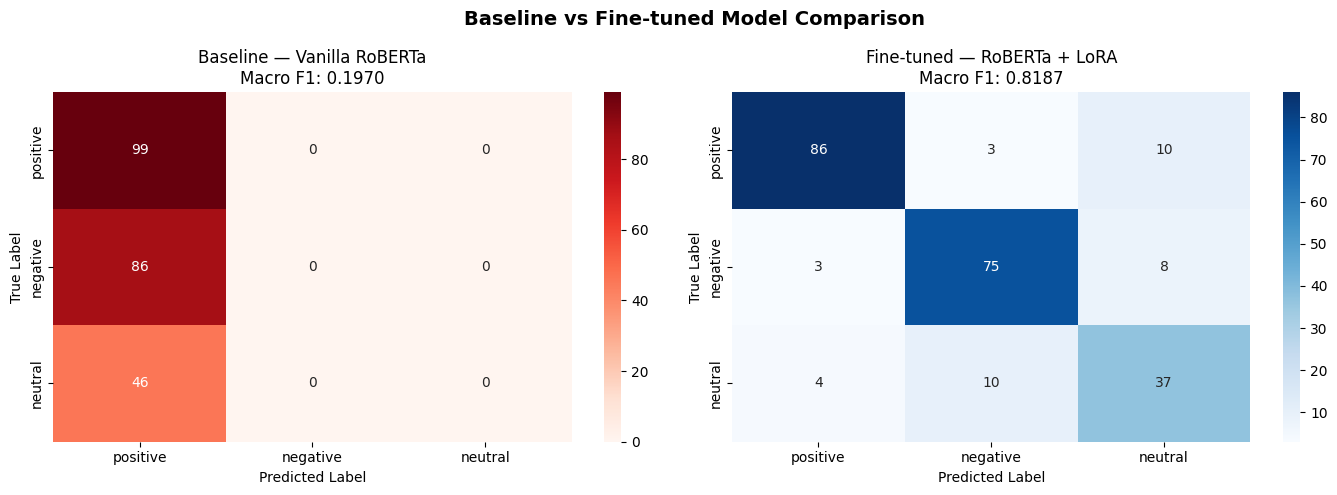


=== FINAL COMPARISON SUMMARY ===

Model                                 Macro F1   Accuracy
---------------------------------------------------------
Vanilla RoBERTa (baseline)              0.1970     0.4195
RoBERTa + LoRA (fine-tuned)             0.8187     0.8390

Absolute improvement — Macro F1 : +0.6217
Absolute improvement — Accuracy : +0.4195


In [49]:
# Cell 41 — Comparison visualization + final summary
cm_baseline  = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])

# Get fine-tuned predictions
finetuned_out    = trainer.predict(test_dataset)
finetuned_preds  = np.argmax(finetuned_out.predictions, axis=-1)
finetuned_labels = finetuned_out.label_ids
cm_finetuned     = confusion_matrix(finetuned_labels, finetuned_preds, labels=[0, 1, 2])

label_names = ["positive", "negative", "neutral"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Reds",
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("Baseline — Vanilla RoBERTa\nMacro F1: 0.1970")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

sns.heatmap(cm_finetuned, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("Fine-tuned — RoBERTa + LoRA\nMacro F1: 0.8187")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.suptitle("Baseline vs Fine-tuned Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Final summary table
finetuned_macro = f1_score(finetuned_labels, finetuned_preds,
                            labels=[0,1,2], average="macro", zero_division=0)
finetuned_acc   = (finetuned_preds == finetuned_labels).mean()
baseline_acc    = (all_preds == all_labels).mean()

print("\n=== FINAL COMPARISON SUMMARY ===\n")
print(f"{'Model':<35} {'Macro F1':>10} {'Accuracy':>10}")
print("-" * 57)
print(f"{'Vanilla RoBERTa (baseline)':<35} {baseline_macro_f1:>10.4f} {baseline_acc:>10.4f}")
print(f"{'RoBERTa + LoRA (fine-tuned)':<35} {finetuned_macro:>10.4f} {finetuned_acc:>10.4f}")
print(f"\nAbsolute improvement — Macro F1 : +{finetuned_macro - baseline_macro_f1:.4f}")
print(f"Absolute improvement — Accuracy : +{finetuned_acc - baseline_acc:.4f}")

In [50]:
# Cell 42 — Save the final fine-tuned model (best checkpoint from trainer)
import os

save_path = "./final-absa-model"
os.makedirs(save_path, exist_ok=True)

# Save model and tokenizer
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# Save config separately for easy reference
import json
config_to_save = {k: v for k, v in CONFIG.items() if not isinstance(v, torch.Tensor)}
with open(os.path.join(save_path, "absa_config.json"), "w") as f:
    json.dump(config_to_save, f, indent=2)

print(f"Model saved to: {save_path}")
print(f"Contents:")
for f in os.listdir(save_path):
    size = os.path.getsize(os.path.join(save_path, f))
    print(f"  {f:<40} {size/1024/1024:.2f} MB")

Model saved to: ./final-absa-model
Contents:
  absa_config.json                         0.00 MB
  adapter_config.json                      0.00 MB
  adapter_model.safetensors                12.41 MB
  tokenizer.json                           3.39 MB
  tokenizer_config.json                    0.00 MB
  README.md                                0.00 MB


In [51]:
# Cell 43 — Verify saved model loads and runs correctly
from peft import PeftModel, PeftConfig

# Load fresh from disk
loaded_tokenizer = AutoTokenizer.from_pretrained(save_path)
loaded_config    = PeftConfig.from_pretrained(save_path)
loaded_model     = AutoModelForSequenceClassification.from_pretrained(
    loaded_config.base_model_name_or_path,
    num_labels = CONFIG["num_labels"],
    id2label   = CONFIG["id2label"],
    label2id   = CONFIG["label2id"],
    ignore_mismatched_sizes = True,
)
loaded_model = PeftModel.from_pretrained(loaded_model, save_path)
loaded_model.to(DEVICE)
loaded_model.eval()

print("Model loaded successfully from disk.\n")

# Quick sanity check inference
def predict_loaded(sentence, aspect):
    enc = loaded_tokenizer(
        sentence, aspect,
        max_length     = CONFIG["max_length"],
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    ).to(DEVICE)
    with torch.no_grad():
        logits = loaded_model(**enc).logits
    probs     = torch.softmax(logits, dim=-1).squeeze(0)
    pred      = CONFIG["id2label"][torch.argmax(probs).item()]
    print(f"Sentence  : {sentence}")
    print(f"Aspect    : {aspect}")
    print(f"Predicted : {pred.upper()}")
    for i, lbl in CONFIG["id2label"].items():
        print(f"  {lbl:10s}: {probs[i].item():.4f}")
    print()

predict_loaded(
    "The battery life on this laptop is absolutely incredible.",
    "battery life"
)
predict_loaded(
    "The customer service took 3 weeks to respond to my email.",
    "customer service"
)
predict_loaded(
    "The screen resolution is 1080p.",
    "screen"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully from disk.

Sentence  : The battery life on this laptop is absolutely incredible.
Aspect    : battery life
Predicted : POSITIVE
  positive  : 0.9952
  negative  : 0.0025
  neutral   : 0.0023

Sentence  : The customer service took 3 weeks to respond to my email.
Aspect    : customer service
Predicted : NEGATIVE
  positive  : 0.0017
  negative  : 0.9955
  neutral   : 0.0028

Sentence  : The screen resolution is 1080p.
Aspect    : screen
Predicted : NEUTRAL
  positive  : 0.0099
  negative  : 0.0063
  neutral   : 0.9838



In [52]:
# Verification cell — run before saving anything
# Check which model is in memory right now
model.eval()

enc = tokenizer(
    "The keyboard feels cheap and breaks after a few weeks.",
    "keyboard",
    max_length=CONFIG["max_length"],
    padding="max_length",
    truncation=True,
    return_tensors="pt",
).to(DEVICE)

with torch.no_grad():
    logits = model(**enc).logits
probs = torch.softmax(logits, dim=-1).squeeze(0)
pred  = CONFIG["id2label"][torch.argmax(probs).item()]

print(f"Prediction : {pred.upper()}")
for i, lbl in CONFIG["id2label"].items():
    print(f"  {lbl:10s}: {probs[i].item():.4f}")

print("\nIf this matches what we saw earlier from the original model,")
print("then 'model' variable is correct and safe to save.")
print("Expected: POSITIVE (this was the known result from the original model)")

Prediction : POSITIVE
  positive  : 0.9522
  negative  : 0.0309
  neutral   : 0.0169

If this matches what we saw earlier from the original model,
then 'model' variable is correct and safe to save.
Expected: POSITIVE (this was the known result from the original model)


In [53]:
# Cell 44 — Zip and download the final model
import shutil

# Create zip of the final model folder
shutil.make_archive(
    base_name = "/kaggle/working/final-absa-model",
    format    = "zip",
    root_dir  = "/kaggle/working",
    base_dir  = "final-absa-model",
)

print("Zip created successfully.")
print("File: /kaggle/working/final-absa-model.zip")

import os
size = os.path.getsize("/kaggle/working/final-absa-model.zip")
print(f"Size: {size/1024/1024:.2f} MB")

Zip created successfully.
File: /kaggle/working/final-absa-model.zip
Size: 12.11 MB
